In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Google Drive is mounted, you can access files from it. For example, to load a CSV file, you can use pandas:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/netflix_titles.csv")

# Basic cleaning so charts work properly
df = df.drop_duplicates()
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df = df.dropna(subset=["date_added", "rating"])
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

sns.set_style("whitegrid")

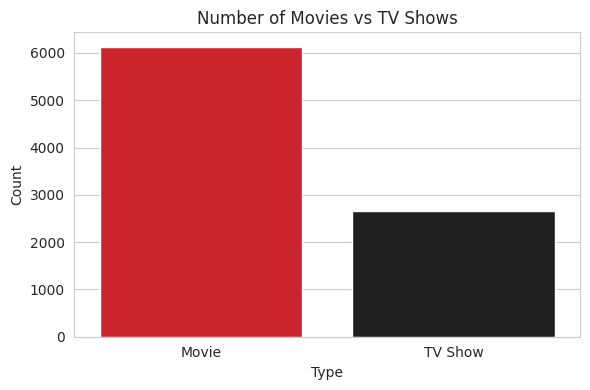

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="type", data=df, hue="type", legend=False, palette=["#E50914", "#221F1F"])
plt.title("Number of Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("/content/viz_1_bar_chart.png", dpi=120)
plt.show()

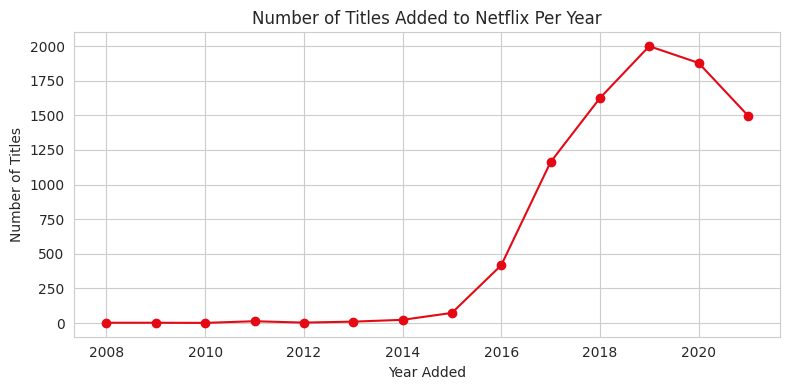

In [ ]:
yearly = df["year_added"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.plot(yearly.index, yearly.values, marker="o", color="#E50914")
plt.title("Number of Titles Added to Netflix Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("/content/viz_2_line_chart.png", dpi=120)
plt.show()

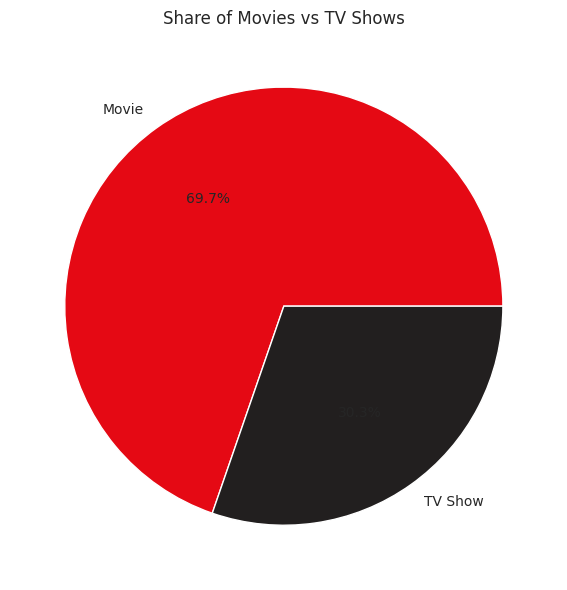

In [ ]:
plt.figure(figsize=(6, 6))
df["type"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", colors=["#E50914", "#221F1F"]
)
plt.title("Share of Movies vs TV Shows")
plt.ylabel("")
plt.tight_layout()
plt.savefig("/content/viz_3_pie_chart.png")

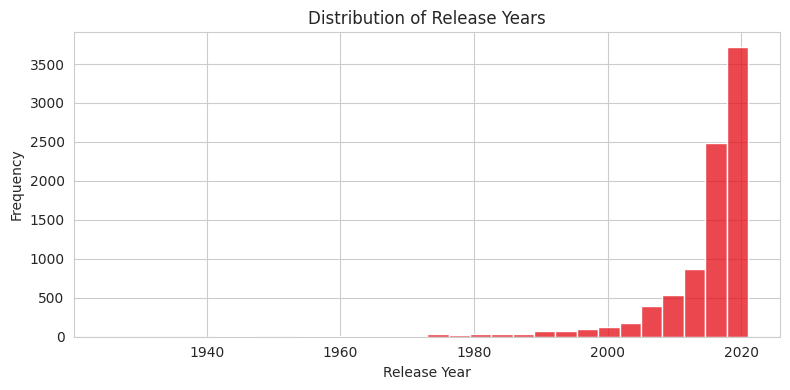

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["release_year"], bins=30, color="#E50914")
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("/content/viz_4_histogram.png", dpi=120)
plt.show()

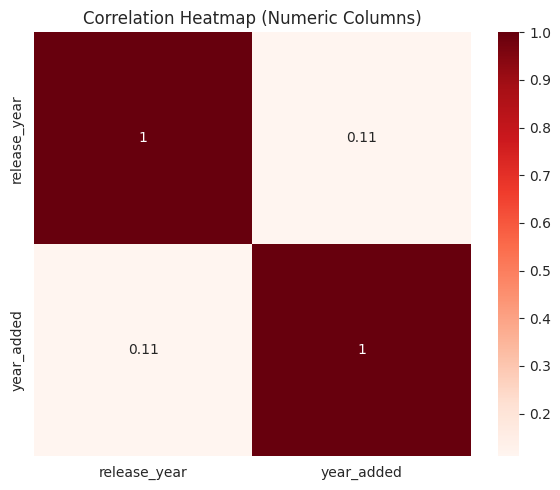

In [ ]:
numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Reds")
plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.savefig("/content/viz_5_heatmap.png", dpi=120)
plt.show()